In [2]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [4]:
# Get olink protein abundance associations
LOCAL_DIR = '/home/dnanexus/data_dir/'

olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05))
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .filter(
        pl.col('region') == 'ENSG00000171862',
    )
)

gene_trait_df

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Initial the exp assay path variable
exp_anno_local = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_expAssays.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""exp_assays""","""scaled_fitness""","""#66BB6A""","""aPCA fitness""",1
"""exp_assays""","""DMS_score_combined""","""#4DB6AC""","""DMS (combined)""",-1
"""exp_assays""","""LDL_uptake_functional""","""#66BB6A""","""LDL uptake functional""",-1
"""exp_assays""","""LDLR_cell_surface_abundance""","""#81C784""","""LDLR cell surface abundance""",-1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
…,…,…,…,…
"""protein_domains""","""low_complexity_domain""","""#FF9933""","""Low Complexity Domain""",1
"""loftee_protein_domains""","""loftee_disorder""","""#E31A1C""","""Disordered Domain""",1
"""loftee_protein_domains""","""loftee_lip""","""#1E90FF""","""Linear Interacting Peptides""",1


In [4]:
exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

# exp_anno_filename = "aPCA_Beltran_Nature_2025.parquet"
# exp_assay_score_columns = ['scaled_fitness']

# exp_anno_filename = "DMS_Marsh_VEP.parquet"
# exp_assay_score_columns = ['scaled_fitness']

# exp_anno_filename = "DMS_ProteinGym_substitutions.parquet"

exp_anno_filename = "LDLR_Roth_Science_2025.parquet"
exp_assay_type_column = 'assay'
exp_assay_score_column = 'score'

LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
!mkdir -p {LOCAL_EXP_DIR}
!dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
exp_anno_df = (
    pl.read_parquet(exp_anno_local)
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .drop_nulls(subset=id_cols)
    # .select(id_cols + exp_assay_type_columns + exp_assay_score_columns)
    .pivot(
        index=id_cols,
        on=exp_assay_type_column,
        values=exp_assay_score_column
    )
)

exp_assay_columns = list(set(exp_anno_df.columns) - set(id_cols))

exp_assay_columns = ['LDL_uptake_functional', 'LDLR_cell_surface_abundance']
exp_anno_df = exp_anno_df.select(id_cols + exp_assay_columns)

exp_anno_df

Error: path
"/home/dnanexus/data_dir/experimental_assays/LDLR_Roth_Science_2025.parquet"
already exists but -f/--overwrite was not set


/tmp/ipykernel_132070/2925430958.py:24: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


ref_aa,aa_position,alt_aa,region,LDL_uptake_functional,LDLR_cell_surface_abundance
str,i64,str,str,f64,f64
"""G""",2,"""L""","""ENSG00000130164""",-0.042187,0.90099
"""G""",2,"""W""","""ENSG00000130164""",0.985631,1.012781
"""G""",2,"""A""","""ENSG00000130164""",0.964176,1.021534
"""G""",2,"""Y""","""ENSG00000130164""",-0.026747,1.062286
"""G""",2,"""M""","""ENSG00000130164""",1.012579,1.130779
…,…,…,…,…,…
"""G""",343,"""Q""","""ENSG00000130164""",null,null
"""A""",348,"""W""","""ENSG00000130164""",null,null
"""A""",348,"""Y""","""ENSG00000130164""",null,null


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if exp_anno_local is not None:
    anno = (
        anno
        .filter(
            pl.col('amino_acids').is_not_null(),
            pl.col('amino_acids').str.contains("/"),
            ~pl.col('protein_position').str.contains("-")
        )
        .with_columns(
            pl.col("amino_acids").str.split("/").list.get(0).alias("ref_aa"),
            pl.col("amino_acids").str.split("/").list.get(1).alias("alt_aa"),
            pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
        )

        .join(
            exp_anno_df.lazy(),
            on=['ref_aa', 'aa_position', 'alt_aa', 'region'],
            how='left'
        )

        # Restrict to variants with experimental assay data
        .drop_nulls(exp_assay_columns)
    )


anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True),
        # (pl.col('consequence_synonymous_variant') == True),

        # Filter for missense variants that we can merge with exp assay data
        # (pl.col('amino_acids').is_not_null()) & (pl.col('amino_acids').str.contains("/")) & (~pl.col('protein_position').str.contains("-")),

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        
        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('mobi_disorder_full') == True),

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    
)



selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # synonymous
# selected_categories = ['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # CDS

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

selected_annos = list(set(selected_annos).intersection(set(existing_annos))) + exp_assay_columns
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_132070/3556430426.py:81: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_132070/3556430426.py:91: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


score_pai3d,gpn_score,am_pathogenicity,cadd_raw,verphylop,id,region,LDLR_cell_surface_abundance,LDL_uptake_functional,esmscoremissense
f32,f32,f32,f32,f32,str,str,f64,f64,f32
0.648151,-6.87,0.554,3.14969,2.245,"""chr19:11105433:G:T""","""ENSG00000130164""",0.951163,0.667086,-9.792
0.169891,4.43,0.0856,-0.600039,2.025,"""chr19:11105459:A:G""","""ENSG00000130164""",0.804304,0.989214,-1.29
0.280219,-2.71,0.121,-0.37179,-1.149,"""chr19:11105564:C:T""","""ENSG00000130164""",0.982623,0.9558,-4.989
0.0,-0.92,0.0,3.922757,-0.151,"""chr19:11105470:C:G""","""ENSG00000130164""",-0.275344,0.151272,0.0
0.0,-7.21,0.0,3.587719,-0.593,"""chr19:11105407:C:A""","""ENSG00000130164""",-0.07941,-0.108479,0.0
…,…,…,…,…,…,…,…,…,…
0.855569,-11.61,0.9451,5.126152,11.131,"""chr19:11116143:G:C""","""ENSG00000130164""",1.118448,1.046837,-9.254
0.666875,-7.42,0.2936,4.084562,8.503,"""chr19:11116150:A:G""","""ENSG00000130164""",1.103772,0.892258,-7.432
0.821483,-6.22,0.9647,4.619923,4.661,"""chr19:11116141:G:A""","""ENSG00000130164""",1.00915,0.956281,-12.779


In [6]:
melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11105433:G:T""","""ENSG00000130164""","""score_pai3d""",0.648151
"""chr19:11105459:A:G""","""ENSG00000130164""","""score_pai3d""",0.169891
"""chr19:11105564:C:T""","""ENSG00000130164""","""score_pai3d""",0.280219
"""chr19:11105470:C:G""","""ENSG00000130164""","""score_pai3d""",0.0
"""chr19:11105407:C:A""","""ENSG00000130164""","""score_pai3d""",0.0
…,…,…,…
"""chr19:11116143:G:C""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",1.118448
"""chr19:11116150:A:G""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",1.103772
"""chr19:11116141:G:A""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",1.00915


In [ ]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Olink APPV: negate mean_pheno_value (descending for olink)
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .with_columns(
        mean_pheno_value = -pl.col('mean_pheno_value')  # Descending for olink
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

In [8]:
from scipy.stats import spearmanr, norm

ci_alpha = 0.05
z_crit = norm.ppf(1 - ci_alpha / 2)  # 1.96 for 95% CI

# --- 1. Collect the pre-correlation data ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

pre_corr_data = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_na' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df["region", "phenotype"].lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .filter(pl.col('annotation') != 'loftee_hc')
    .collect(engine='streaming')
)

# --- 2. Spearman correlation with Fisher Z-transformation CI ---
# results = []

# for (region, phenotype, annotation), group in pre_corr_data.group_by(['region', 'phenotype', 'annotation']):
#     scores = group['annotation_score'].to_numpy().astype(np.float64)
#     pheno_vals = group['mean_pheno_value'].to_numpy().astype(np.float64)
    
#     # Drop NaN pairs
#     mask = ~(np.isnan(scores) | np.isnan(pheno_vals))
#     scores, pheno_vals = scores[mask], pheno_vals[mask]
#     n = len(scores)
    
#     if n < 3 or len(np.unique(scores)) < 2 or len(np.unique(pheno_vals)) < 2:
#         continue
    
#     # Original correlation
#     orig_corr, _ = spearmanr(scores, pheno_vals)
    
#     # Fisher Z-transformation for CI
#     z = np.arctanh(orig_corr)
#     se_z = 1 / np.sqrt(n - 3)
#     z_ci_low = z - z_crit * se_z
#     z_ci_high = z + z_crit * se_z
#     ci_low = np.tanh(z_ci_low)
#     ci_high = np.tanh(z_ci_high)
    
#     results.append({
#         'region': region, 
#         'phenotype': phenotype, 
#         'annotation': annotation,
#         'n_variants': n, 
#         'correlation': orig_corr, 
#         'ci_low': ci_low, 
#         'ci_high': ci_high,
#     })

# final_lazy_plan = pl.DataFrame(results)

# # --- 3. Join with beta directions and annotation directions ---
# correlation_df = (
#     final_lazy_plan
#     .join(anno_config_df.drop('category').unique(), on='annotation')
#     .join(gene_trait_df, on=['region', 'phenotype'])
#     .with_columns(
#         corr_beta = pl.col('correlation') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
#         ci_low_beta = pl.col('ci_low') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
#         ci_high_beta = pl.col('ci_high') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
#     )
#     # When direction flips the sign, ci_low/ci_high swap — fix ordering
#     .with_columns(
#         ci_low_beta_final = pl.min_horizontal('ci_low_beta', 'ci_high_beta'),
#         ci_high_beta_final = pl.max_horizontal('ci_low_beta', 'ci_high_beta'),
#     )
#     .drop(['ci_low_beta', 'ci_high_beta'])
#     .rename({'ci_low_beta_final': 'ci_low_beta', 'ci_high_beta_final': 'ci_high_beta'})
# )

# print("Final DataFrame shape:", correlation_df.shape)
# correlation_df

In [9]:

# consistent_gt = (
#     correlation_df
#     .drop_nulls().drop_nans()
#     .group_by(['region', 'phenotype'])
#     .agg(n_annotations = pl.len())
#     .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
# )

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 20)
# filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
# filt_corr_df

In [10]:
# annos_w_inconsistent_assocs = (
#     filt_corr_df
#     .drop_nulls().drop_nans()
#     .select(['region', 'phenotype', 'annotation'])
#     .group_by('annotation')
#     .agg(n_associations = pl.len())
#     .select('n_associations').n_unique()
# ) - 1

# print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# # Check if the variant counts are consistent within each (region, phenotype) pair
# var_inconsistent = (
#     filt_corr_df
#     .drop_nans()
#     .drop_nulls()
#     .group_by(["region", "phenotype"])
#     .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
#     .filter(pl.col("n_variants_unique") > 1)
# )
# print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

In [11]:
# plotting_col = 'corr_beta'
# dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# # Calculate medians and join back
# corr_pl = (
#     filt_corr_df
#     .drop_nans()
#     .with_columns(
#         median_corr_beta = pl.col(plotting_col).median().over("annotation")
#     )
# )

# # 2. Determine the categorical order for the labels
# ordered_labels = (
#     corr_pl
#     .sort("median_corr_beta", descending=False)
#     .select("label")
#     .unique(maintain_order=True)
#     .to_series()
# )

# # 3. Apply the ordering using pl.Enum
# corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# # 4. Create the color dictionary (Polars style)
# color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# # Plot
# (
#     ggplot(corr_pl, aes(x="label", y=plotting_col))
#     # + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
#     + geom_point(size=1.5)
#     + geom_errorbar(aes(ymin="ci_low_beta", ymax="ci_high_beta"), width=0.25)
#     + theme_minimal()
#     + scale_fill_manual(values=color_dict)
#     + labs(
#         x="",
#         y="Spearman correlation",
#         title=f"{exp_anno_filename.replace('.parquet', '')}, Fisher Z CI"
#     )
#     + coord_flip()
#     + theme(
#         figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
#         legend_position="none",
#         axis_text=element_text(size=13),
#         axis_title=element_text(size=13),
#         legend_text=element_text(size=13),
#         legend_title=element_text(size=13),
#         plot_background=element_rect(fill="white", color="white"),
#     )
# )

In [12]:
# Get variant ID to amino acid position mapping from the annotation parquet
anno_with_pos = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(
        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-"),
        pl.col('region').is_in(gene_trait_df['region'].unique()),
    )
    .with_columns(
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .select(['id', 'aa_position'])
    .unique()
    .collect()
)

# Add position to pre_corr_data
pre_corr_pos = pre_corr_data.join(anno_with_pos, on='id', how='inner')
print(f"Variants with position: {pre_corr_pos['id'].n_unique()} / {pre_corr_data['id'].n_unique()}")
print(f"Position range: {pre_corr_pos['aa_position'].min()} - {pre_corr_pos['aa_position'].max()}")
pre_corr_pos.head()

/tmp/ipykernel_132070/1695067443.py:15: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Variants with position: 398 / 398
Position range: 3 - 856


id,phenotype,mean_pheno_value,n_individuals,region,annotation,annotation_score,aa_position
str,str,f32,i32,str,str,f32,i64
"""chr19:11105538:A:C""","""ldl_direct_int""",-0.765437,1,"""ENSG00000130164""","""score_pai3d""",0.586524,211
"""chr19:11105538:A:C""","""ldl_direct_int""",-0.765437,1,"""ENSG00000130164""","""gpn_score""",-6.74,211
"""chr19:11105538:A:C""","""ldl_direct_int""",-0.765437,1,"""ENSG00000130164""","""am_pathogenicity""",0.1283,211
"""chr19:11105538:A:C""","""ldl_direct_int""",-0.765437,1,"""ENSG00000130164""","""cadd_raw""",3.555138,211
"""chr19:11105538:A:C""","""ldl_direct_int""",-0.765437,1,"""ENSG00000130164""","""verphylop""",3.698,211


In [13]:
from scipy.stats import spearmanr

def compute_running_correlations(df, window_size=100, step_size=5, min_variants=15):
    """
    Compute running Spearman correlations along the protein.
    
    Uses a sliding window of `window_size` amino acid positions,
    stepped by `step_size` positions. Requires at least `min_variants`
    non-null pairs in each window.
    """
    results = []
    
    for annotation in df['annotation'].unique():
        anno_df = df.filter(pl.col('annotation') == annotation).sort('aa_position')
        
        positions = anno_df['aa_position'].to_numpy()
        scores = anno_df['annotation_score'].to_numpy().astype(np.float64)
        pheno = anno_df['mean_pheno_value'].to_numpy().astype(np.float64)
        
        pos_min, pos_max = int(positions.min()), int(positions.max())
        half_w = window_size // 2
        
        for center in range(pos_min + half_w, pos_max - half_w + 1, step_size):
            lo = center - half_w
            hi = center + half_w
            
            mask = (positions >= lo) & (positions <= hi) & ~np.isnan(scores) & ~np.isnan(pheno)
            n = mask.sum()
            
            if n >= min_variants and len(np.unique(scores[mask])) > 1 and len(np.unique(pheno[mask])) > 1:
                corr, pval = spearmanr(scores[mask], pheno[mask])
                results.append({
                    'annotation': annotation,
                    'center_position': center,
                    'window_start': lo,
                    'window_end': hi,
                    'n_variants': int(n),
                    'correlation': corr,
                    'pval': pval,
                })
    
    return pl.DataFrame(results)

# Parameters — adjust as needed
window_size = 100   # amino acid positions wide
step_size = 1       # slide by 5 positions
min_variants = 15   # minimum variants per window

running_corr = compute_running_correlations(
    pre_corr_pos,
    window_size=window_size,
    step_size=step_size,
    min_variants=min_variants,
)

# Adjust correlation direction (same logic as the overall correlations)
running_corr = (
    running_corr
    .join(anno_config_df.select(['annotation', 'annotation_dir', 'label', 'color']), on='annotation')
    .join(gene_trait_df.select(['loftee_corr_dir']).unique(), how='cross')
    .with_columns(
        corr_beta = pl.col('correlation') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
    )
)

print(f"Running correlation results: {running_corr.shape}")
print(f"Annotations: {running_corr['annotation'].unique().to_list()}")
running_corr.head(10)

Running correlation results: (6032, 12)
Annotations: ['esmscoremissense', 'verphylop', 'LDLR_cell_surface_abundance', 'cadd_raw', 'score_pai3d', 'LDL_uptake_functional', 'am_pathogenicity', 'gpn_score']


annotation,center_position,window_start,window_end,n_variants,correlation,pval,annotation_dir,label,color,loftee_corr_dir,corr_beta
str,i64,i64,i64,i64,f64,f64,i8,str,str,f64,f64
"""score_pai3d""",53,3,103,44,0.39253,0.008401,1,"""PrimateAI-3D""","""#feb72d""",1.0,0.39253
"""score_pai3d""",54,4,104,43,0.366959,0.015499,1,"""PrimateAI-3D""","""#feb72d""",1.0,0.366959
"""score_pai3d""",55,5,105,43,0.356539,0.018936,1,"""PrimateAI-3D""","""#feb72d""",1.0,0.356539
"""score_pai3d""",56,6,106,44,0.342636,0.022801,1,"""PrimateAI-3D""","""#feb72d""",1.0,0.342636
"""score_pai3d""",57,7,107,44,0.342636,0.022801,1,"""PrimateAI-3D""","""#feb72d""",1.0,0.342636
"""score_pai3d""",58,8,108,45,0.340975,0.021898,1,"""PrimateAI-3D""","""#feb72d""",1.0,0.340975
"""score_pai3d""",59,9,109,47,0.393386,0.006228,1,"""PrimateAI-3D""","""#feb72d""",1.0,0.393386
"""score_pai3d""",60,10,110,46,0.427567,0.003038,1,"""PrimateAI-3D""","""#feb72d""",1.0,0.427567
"""score_pai3d""",61,11,111,45,0.433202,0.002954,1,"""PrimateAI-3D""","""#feb72d""",1.0,0.433202


In [ ]:
# Plot running Spearman correlations along LDLR protein (Olink protein abundance)
color_dict = dict(running_corr.select("label", "color").unique().iter_rows())

(
    ggplot(running_corr, aes(x="center_position", y="corr_beta", color="label"))
    + geom_line(size=1, alpha=0.85)
    + geom_hline(yintercept=0, linetype='dashed', color='grey', alpha=0.7)
    + theme_minimal()
    + scale_color_manual(values=color_dict)
    + labs(
        x="Amino acid position",
        y="Spearman correlation (direction-adjusted)",
        title=f"Running Spearman correlation along LDLR (Olink protein abundance)\n(window={window_size} aa, step={step_size}, min variants={min_variants})",
        color="Annotation",
    )
    + theme(
        figure_size=(14, 6),
        axis_text=element_text(size=12),
        axis_title=element_text(size=13),
        legend_text=element_text(size=11),
        legend_title=element_text(size=12),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [ ]:
# Faceted plot: one panel per annotation for cleaner comparison
(
    ggplot(running_corr, aes(x="center_position", y="corr_beta", color="label"))
    + geom_line(size=1)
    + geom_hline(yintercept=0, linetype='dashed', color='grey', alpha=0.7)
    + facet_wrap("~label", ncol=2, scales="free_y")
    + theme_minimal()
    + scale_color_manual(values=color_dict)
    + labs(
        x="Amino acid position",
        y="Spearman ρ (direction-adjusted)",
        title=f"Running Spearman correlation along LDLR by annotation (Olink protein abundance)\n(window={window_size} aa)",
    )
    + theme(
        figure_size=(14, 3 * ((running_corr['label'].n_unique() + 1) // 2)),
        legend_position="none",
        axis_text=element_text(size=10),
        axis_title=element_text(size=12),
        strip_text=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)

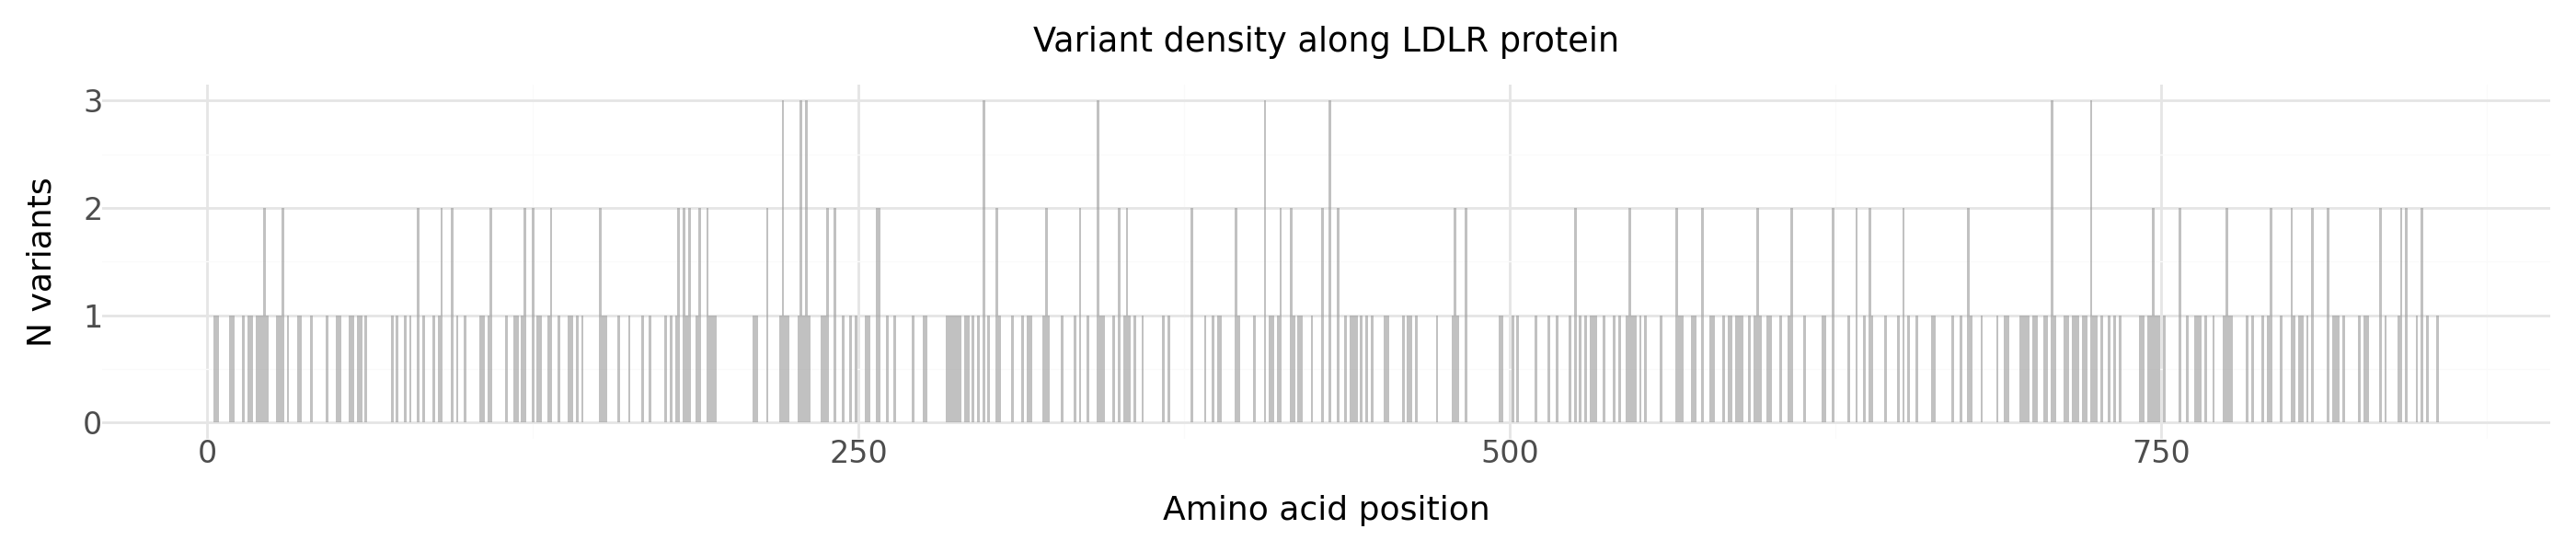

In [16]:
# Variant density along the protein (useful context for interpreting correlation dips)
# Uses the same pre_corr_pos data, taking one annotation to count unique variants per position
variant_positions = (
    pre_corr_pos
    .select(['id', 'aa_position'])
    .unique()
    .group_by('aa_position')
    .agg(n_variants=pl.len())
    .sort('aa_position')
)

(
    ggplot(variant_positions, aes(x="aa_position", y="n_variants"))
    + geom_col(fill="#999999", alpha=0.6, width=1)
    + theme_minimal()
    + labs(
        x="Amino acid position",
        y="N variants",
        title="Variant density along LDLR protein",
    )
    + theme(
        figure_size=(14, 3),
        axis_text=element_text(size=12),
        axis_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [17]:
# Extract domain annotations per amino acid position
domain_cols = ['mobi_curated_disorder_priority', 'mobi_lip_full', 'ted_domain', 'low_complexity_domain']

domain_df = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(
        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-"),
        pl.col('region').is_in(gene_trait_df['region'].unique()),
    )
    .with_columns(
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .select(['aa_position'] + domain_cols)
    .group_by('aa_position')
    .agg([pl.col(c).max().alias(c) for c in domain_cols])  # any True at this position
    .sort('aa_position')
    .collect()
)

# Build contiguous domain intervals for plotting as horizontal bars
domain_labels = {
    'ted_domain': 'Structured Domain (TED)',
    'mobi_curated_disorder_priority': 'Disordered Region',
    'mobi_lip_full': 'Linear Interacting Peptide',
    'low_complexity_domain': 'Low Complexity',
}
domain_colors = {
    'ted_domain': '#2E8B57',
    'mobi_curated_disorder_priority': '#E31A1C',
    'mobi_lip_full': '#1E90FF',
    'low_complexity_domain': '#FF9933',
}

def get_intervals(positions, values):
    """Return list of (start, end) intervals where values are True."""
    intervals = []
    in_region = False
    for pos, val in zip(positions, values):
        if val and not in_region:
            start = pos
            in_region = True
        elif not val and in_region:
            intervals.append((start, prev_pos))
            in_region = False
        prev_pos = pos
    if in_region:
        intervals.append((start, prev_pos))
    return intervals

domain_intervals = {}
positions = domain_df['aa_position'].to_numpy()
for col in domain_cols:
    vals = domain_df[col].to_numpy().astype(bool)
    domain_intervals[col] = get_intervals(positions, vals)

print("Domain intervals:")
for col, intervals in domain_intervals.items():
    print(f"  {domain_labels[col]}: {intervals}")

/tmp/ipykernel_132070/3434779060.py:19: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Domain intervals:
  Disordered Region: [(np.int64(4), np.int64(275)), (np.int64(354), np.int64(389)), (np.int64(714), np.int64(787))]
  Linear Interacting Peptide: [(np.int64(9), np.int64(16)), (np.int64(46), np.int64(62)), (np.int64(81), np.int64(106)), (np.int64(119), np.int64(144)), (np.int64(162), np.int64(184)), (np.int64(213), np.int64(231)), (np.int64(253), np.int64(271)), (np.int64(314), np.int64(344)), (np.int64(358), np.int64(362)), (np.int64(399), np.int64(399)), (np.int64(663), np.int64(663)), (np.int64(705), np.int64(705)), (np.int64(720), np.int64(725)), (np.int64(730), np.int64(732)), (np.int64(753), np.int64(770)), (np.int64(783), np.int64(829))]
  Structured Domain (TED): [(np.int64(210), np.int64(249)), (np.int64(284), np.int64(335)), (np.int64(399), np.int64(653))]
  Low Complexity: [(np.int64(791), np.int64(808))]


In [20]:
running_corr['annotation'].unique()

annotation
str
"""LDLR_cell_surface_abundance"""
"""am_pathogenicity"""
"""gpn_score"""
"""score_pai3d"""
"""cadd_raw"""
"""esmscoremissense"""
"""verphylop"""
"""LDL_uptake_functional"""


In [ ]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec


annos2plot = ['am_pathogenicity', 'esmscoremissense', 'gpn_score', 'LDL_uptake_functional']
running_corr_plot = (
    running_corr
    .filter(pl.col('annotation').is_in(annos2plot))
)

# Build the combined figure: running correlations + domain track
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(2, 1, height_ratios=[5, 1.2], hspace=0.08)

ax_corr = fig.add_subplot(gs[0])
ax_dom = fig.add_subplot(gs[1], sharex=ax_corr)

# --- Top panel: running correlations ---
color_dict_label = dict(running_corr_plot.select("label", "color").unique().iter_rows())

for label in running_corr_plot['label'].unique().sort():
    sub = (
        running_corr_plot
        .filter(pl.col('label') == label)
        .sort('center_position')
    )
    ax_corr.plot(
        sub['center_position'].to_numpy(),
        sub['corr_beta'].to_numpy(),
        label=label,
        color=color_dict_label[label],
        linewidth=1.5,
        alpha=0.85,
    )

ax_corr.axhline(0, color='grey', linestyle='--', alpha=0.7)
ax_corr.set_ylabel("Spearman ρ (direction-adjusted)", fontsize=13)
ax_corr.set_title(
    f"Running Spearman correlation along LDLR — Olink protein abundance (window={window_size} aa, step={step_size})",
    fontsize=14,
)
ax_corr.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax_corr.tick_params(axis='x', labelbottom=False)
ax_corr.grid(axis='y', alpha=0.3)

# --- Bottom panel: domain track ---
track_height = 0.6
active_domains = [col for col in domain_cols if len(domain_intervals[col]) > 0]

for i, col in enumerate(active_domains):
    y_center = i
    for start, end in domain_intervals[col]:
        ax_dom.barh(
            y_center, end - start, left=start,
            height=track_height,
            color=domain_colors[col],
            edgecolor='none',
            alpha=0.8,
        )

ax_dom.set_yticks(range(len(active_domains)))
ax_dom.set_yticklabels([domain_labels[c] for c in active_domains], fontsize=10)
ax_dom.set_xlabel("Amino acid position", fontsize=13)
ax_dom.set_ylim(-0.5, len(active_domains) - 0.5)
ax_dom.invert_yaxis()
ax_dom.tick_params(axis='y', length=0)
ax_dom.grid(axis='x', alpha=0.3)

# Clean up spines
for ax in [ax_corr, ax_dom]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()